In [3]:
# from brian2 import *
# from scipy import integrate
# from scipy.integrate import odeint
# from scipy.optimize import curve_fit

# sys.path.append('../scripts_analysis')
# # sys.path.append('../steps')
# # sys.path.append('../../scripts')
# from analysis import *
# from peaks import *
# from misc import *

# from spike_tools import *

# import matplotlib as mpl
# from cycler import cycler

# BrianLogger.suppress_hierarchy('brian2.groups.group.Group.resolve.resolution_conflict')
# BrianLogger.suppress_hierarchy('brian2.codegen')

# plt.style.use('dark_background')
# mpl.rcParams['axes.prop_cycle'] = cycler(color=cpall)
# plt.rcParams.update(plt.rcParamsDefault)

# resultPath = "../data/control/"

# dirs = [a for a in getDirs(resultPath, sstr='nVDCC')]# if "bISI" in a]
# dirs = np.array(dirs)
# # for i,d in enumerate(dirs): print(i, d)

# rep_des_path = "../model_mcell/representative_designs.txt"
# with open(rep_des_path, 'r') as f:
#     rep_designs = [a.strip() for a in f.readlines()]

# rep_designs

In [4]:
import sys, os
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt

from brian2 import *

BrianLogger.suppress_hierarchy('brian2.groups.group.Group.resolve.resolution_conflict')
BrianLogger.suppress_hierarchy('brian2.codegen')

In [5]:
def get_MFB_params(design, param_path):
    ## read 'MFB_design_params.pkl'
    with open(param_path, "rb") as infile:
        MFB_design_params = pk.load(infile)

    # print(MFB_design_params)
    return MFB_design_params[design]

def get_vrel_times(rate, n, dt=0.0001):
    """
    rate (Hz): vesicle release rate
    return: times at which vesicle release occurs for `n` neurons
    """

    ## generate random uniform numbers
    rr = np.random.uniform(size=(n, rate.shape[0]))
    mask = (rate*dt - rr > 0)
    
    neuron_id, vrel_times = np.argwhere(mask).T
    vrel_times = np.array(vrel_times, dtype='float')*dt

    return neuron_id, vrel_times

def getSimInfo(dname, key=None, skip=1):
    infoList = dname.split('_')[skip:]
    if key:
        info = infoList[infoList.index(key)+1]
    else:
        info = dict([[infoList[i], infoList[i+1]] for i in range(0,len(infoList),2)])
    return info

In [6]:
def gen_MFB_vrel(DG_spikes, runt, N, design='nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10', param_path='MFB_design_params.pkl'):
    """
    DG_spikes: list of spiketimes (ms) of the DG neurons
    param_path: path to 'MFB_design_params.pkl' which contains the parameters for `design`
    """

    ## get MFB parameters
    MFB_params = get_MFB_params(design, param_path)
    print(MFB_params)

    ## MFB model equations (generates vesicle release rates)
    eqnMFB = '''
    #Facilitation dynamics
    du/dt = -u/tau_u : 1
    dx/dt = (1-x)/tau_x : 1
    dw/dt = -w/tau_w : 1

    dpCa/dt = (w - pCa)/tau_pCa : 1
    dbCa/dt = w/W + (Ca0 - bCa)/tau_bCa : 1
    drrp/dt = (-w + 1 - rrp)/tau_rrp : 1

    dsyncRel/dt = S*rrp*pCa*w - syncRel/tau_syncRel : 1
    dasyncRel/dt = A*rrp*bCa*w - asyncRel/tau_asyncRel : 1
    '''
    
    updates = '''
    u += U_SE * (1 - u)
    x -= u * x
    w += A_SE * u * x
    '''
    start_scope()

    nMFB = 1
    MFB = NeuronGroup(nMFB, eqnMFB, method='euler', namespace=MFB_params)
    MFB.bCa = MFB_params['Ca0']
    MFB.rrp = 1
    MFB.x = 1

    MFBinp = SpikeGeneratorGroup(1, [0]*len(DG_spikes), DG_spikes)

    ### Synapses
    S_MFBinp_MFB = Synapses(MFBinp, MFB, on_pre=updates, namespace=MFB_params)
    S_MFBinp_MFB.connect(i=0, j=range(nMFB))

    stMMFB = StateMonitor(MFB, variables=['syncRel', 'asyncRel'], record=True)
    # spMMFB = SpikeMonitor(MFB)
    # spMMFBinp = SpikeMonitor(MFBinp)

    run(runt*ms)

    srate, asrate = stMMFB.syncRel[0], stMMFB.asyncRel[0]
    vrel_rate = srate + asrate

    dt = (stMMFB.t[1] - stMMFB.t[0])/second

    # plt.figure(figsize=(6,2))
    # plt.plot(stMMFB.t/second, stMMFB.syncRel[0]+stMMFB.asyncRel[0])
    

    return get_vrel_times(vrel_rate, n=N, dt=dt)

In [7]:
d = 'nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10'
# d = rep_designs[43]
print('Directory: ', d)

simInfo = getSimInfo(d, skip=0)
ISI, nAP, RRP = int(simInfo['ISI']), int(simInfo['nAP']), simInfo['RRP']
runt = nAP*ISI
DG_spikes = np.sort([1.5 + na*ISI for na in range(nAP)])/1000*second

neuron_id, vrel_times = gen_MFB_vrel(DG_spikes, runt, 1000, design=d)

Directory:  nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
{'Ca0': 0.1, 'tau_pCa': 100. * usecond, 'tau_bCa': 40. * msecond, 'tau_syncRel': 0.4 * msecond, 'tau_asyncRel': 30. * msecond, 'tau_rrp': 0.5 * second, 'tau_u': 40. * msecond, 'tau_x': 10. * msecond, 'tau_w': 1. * msecond, 'w0': 1, 'A_SE': 10, 'U_SE': 0.05, 'S': 0.95 * Mhertz, 'A': 60. * khertz, 'W': 1. * msecond}


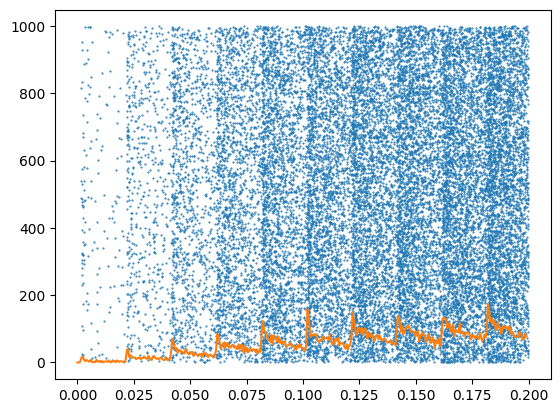

In [8]:
bins = np.arange(0,0.2, 0.0005)
n, _ = np.histogram(vrel_times, bins=bins)
plt.plot(vrel_times, neuron_id, '.', markersize=1)
plt.plot(bins[:-1], n)
